In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"


<Figure size 600x600 with 0 Axes>

Text(0.5, 1.0, 'Original Image')

(-0.5, 1279.5, 852.5, -0.5)

<Figure size 600x600 with 0 Axes>

(array([1.347e+03, 2.204e+03, 2.232e+03, 3.144e+03, 3.980e+03, 5.812e+03,
        8.259e+03, 6.280e+03, 5.700e+03, 5.782e+03, 5.599e+03, 5.563e+03,
        5.580e+03, 5.271e+03, 5.473e+03, 5.162e+03, 5.164e+03, 5.037e+03,
        4.911e+03, 4.847e+03, 4.932e+03, 4.671e+03, 4.909e+03, 4.814e+03,
        4.715e+03, 4.721e+03, 4.597e+03, 4.752e+03, 4.669e+03, 4.719e+03,
        4.645e+03, 4.742e+03, 4.690e+03, 4.632e+03, 4.802e+03, 4.793e+03,
        4.727e+03, 4.809e+03, 4.867e+03, 4.702e+03, 5.142e+03, 5.024e+03,
        4.932e+03, 5.088e+03, 5.070e+03, 5.120e+03, 5.283e+03, 5.287e+03,
        5.209e+03, 5.413e+03, 5.374e+03, 5.380e+03, 5.394e+03, 5.500e+03,
        5.444e+03, 5.425e+03, 5.573e+03, 5.486e+03, 5.662e+03, 5.707e+03,
        5.582e+03, 5.711e+03, 5.633e+03, 5.688e+03, 5.862e+03, 5.860e+03,
        5.891e+03, 5.820e+03, 5.687e+03, 5.827e+03, 5.749e+03, 5.805e+03,
        5.789e+03, 5.857e+03, 5.822e+03, 5.704e+03, 5.714e+03, 5.728e+03,
        5.597e+03, 5.574e+03, 5.581e+0

...

Text(0, 0.5, 'Frequency')

Text(0.5, 1.0, 'Intensity Distribution')

<Figure size 600x600 with 0 Axes>

Text(0.5, 1.0, 'S (Saturation) Channel of HSV image')

(-0.5, 1279.5, 852.5, -0.5)

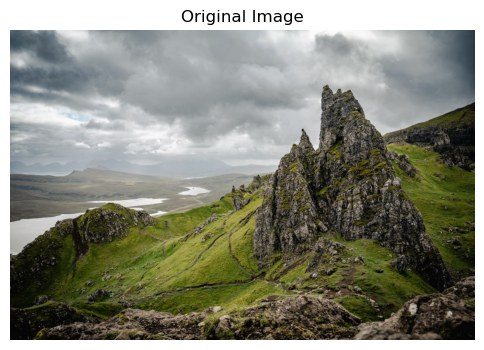

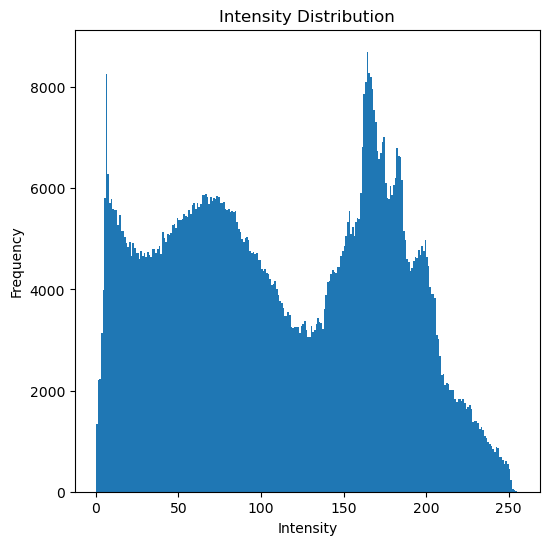

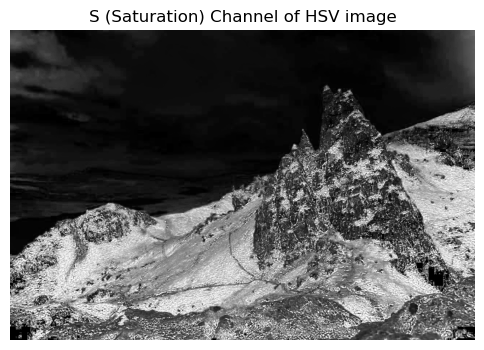

<Figure size 600x600 with 0 Axes>

Text(0.5, 1.0, 'K-means with 32 Colors')

(-0.5, 1279.5, 852.5, -0.5)

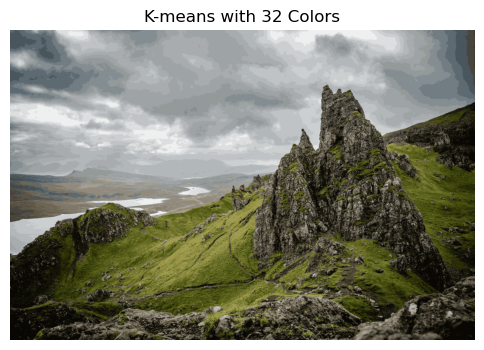

<Figure size 600x600 with 0 Axes>

Text(0.5, 1.0, 'K-means with 16 Colors')

(-0.5, 1279.5, 852.5, -0.5)

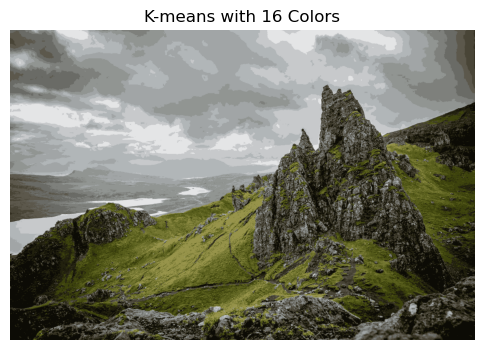

<Figure size 600x600 with 0 Axes>

Text(0.5, 1.0, 'K-means with 8 Colors')

(-0.5, 1279.5, 852.5, -0.5)

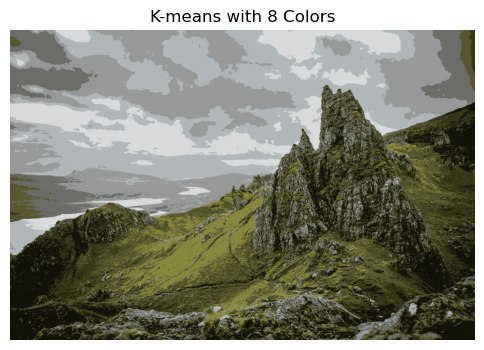

<Figure size 600x600 with 0 Axes>

Text(0.5, 1.0, 'K-means with 4 Colors')

(-0.5, 1279.5, 852.5, -0.5)

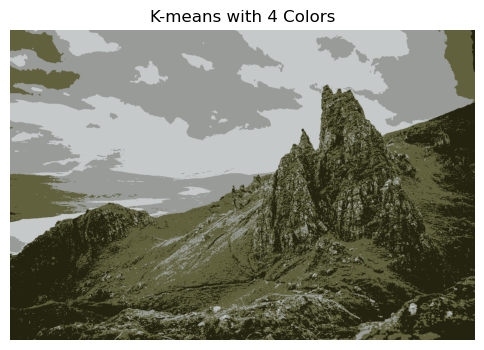

<Figure size 600x600 with 0 Axes>

Text(0.5, 1.0, 'K-means with 2 Colors')

(-0.5, 1279.5, 852.5, -0.5)

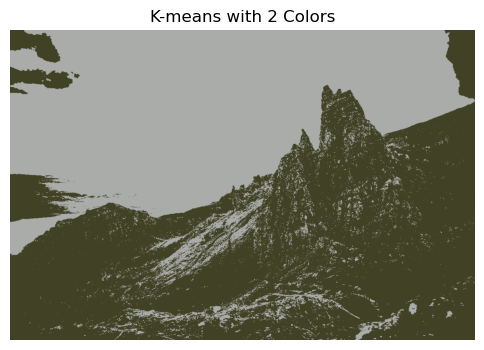

<Figure size 600x600 with 0 Axes>

Text(0.5, 1.0, 'K-means with 1 Colors')

(-0.5, 1279.5, 852.5, -0.5)

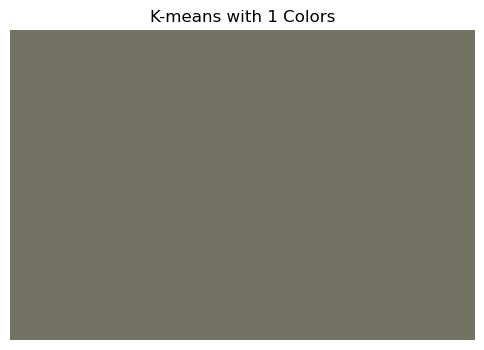

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv 
from sklearn.cluster import KMeans

# Loading the image using OpenCV
image_path = "Stones.jpg"
image = cv.imread(image_path)

# Converting the image to RGB format
image = cv.cvtColor(image, cv.COLOR_BGR2RGB)

# Displaying the original image
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.title("Original Image")
plt.axis('off')

# Converting the image to grayscale for intensity analysis
gray_image = cv.cvtColor(image, cv.COLOR_BGR2GRAY)

# Calculating the histogram of the grayscale image
hist = cv.calcHist([gray_image], [0], None, [256], [0, 256])

# Plotting the histogram
plt.figure(figsize=(6, 6))
plt.hist(gray_image.ravel(), 256, [0, 256])
plt.xlabel('Intensity')
plt.ylabel('Frequency')
plt.title('Intensity Distribution')

hsv_image = cv.cvtColor(image, cv.COLOR_BGR2HSV)

s_channel = hsv_image[:, :, 1]

plt.figure(figsize=(6, 6))
plt.imshow(s_channel, cmap='gray')
plt.title('S (Saturation) Channel of HSV image')
plt.axis('off')  
plt.show()

# Converting the image to a NumPy array
image_array = np.array(image)

# Function to perform K-means quantization
def kmeans_quantization(image_array, n_colors):
    # Flattening the image array
    height, width, channels = image_array.shape
    pixels = image_array.reshape(-1, channels)

    kmeans = KMeans(n_clusters=n_colors, random_state=0)
    kmeans.fit(pixels)
    labels = kmeans.predict(pixels)
    quantized_palette = kmeans.cluster_centers_.astype(int)
    quantized_pixels = quantized_palette[labels].reshape(image_array.shape)
    return quantized_pixels

# Performing K-means quantization with 32, 16, 8, 4, 2, and 1 colors
quantized_32_colors = kmeans_quantization(image_array, n_colors=32)
quantized_16_colors = kmeans_quantization(image_array, n_colors=16)
quantized_8_colors = kmeans_quantization(image_array, n_colors=8)
quantized_4_colors = kmeans_quantization(image_array, n_colors=4)
quantized_2_colors = kmeans_quantization(image_array, n_colors=2)
quantized_1_color = kmeans_quantization(image_array, n_colors=1)

# Displaying the quantized images
quantized_images = [quantized_32_colors, quantized_16_colors, quantized_8_colors, 
                    quantized_4_colors, quantized_2_colors, quantized_1_color]
color_counts = [32, 16, 8, 4, 2, 1]

for i, quantized_image in enumerate(quantized_images):
    plt.figure(figsize=(6, 6))
    plt.imshow(quantized_image)
    plt.title(f"K-means with {color_counts[i]} Colors")
    plt.axis('off')
    plt.show()
